# Inferencia Estadística y Modelado

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm

from scipy import stats
from statsmodels.formula.api import ols
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

In [2]:
df = pd.read_csv('techstore_data.csv')
df.head()

,cliente_id,edad,genero,tipo_cliente,region,monto_compra,tiempo_navegacion,productos_vistos,uso_chatbot_ia,compro,satisfaccion,dia_semana,hora_visita
0,C0001,55,F,Recurrente,Norte,0.00,0.2,7,No,0,4,Viernes,18
1,C0002,43,M,Recurrente,Oeste,288.87,69.1,7,No,1,5,Sabado,15
2,C0003,32,F,Nuevo,Este,424.13,16.6,9,No,1,4,Lunes,19
3,C0004,33,F,Nuevo,Oeste,463.86,22.2,3,Si,1,4,Domingo,20
4,C0005,45,M,Nuevo,Sur,129.14,0.3,7,No,1,4,Sabado,14


# Módulo A: Estimación y Tamaño de Muestra

## 1. Cálculo de Tamaño de Muestra

---

**Orden:** ¿Qué tamaño de muestra se necesita para estimar el *monto_compra*  promedio  con  un  error  máximo  de  $10  y  un  nivel  de confianza  del  95%?  

*Utilice  la  desviación  estándar  muestral calculada previamente.*

---

**Fórmula a utilizar:**
$
n = \left( \frac{Z_{\alpha/2} \cdot \sigma}{E} \right)^2
$

In [3]:
sample_std = np.std(df['monto_compra'], ddof=1)
max_error = 10
confidence_level = 0.95

z_95 = stats.norm.ppf((1 - confidence_level) / 2)
n_required = ((z_95 * sample_std) / max_error) ** 2
n_required = int(np.ceil(n_required))

print(f'Desviación estándar de la muestra: {sample_std}')
print(f'Z para 95% de confianza: {z_95}')
print(f'Tamaño de muestra requerido: {n_required}')

Desviación estándar de la muestra: 197.85817466848997
Z para 95% de confianza: -1.959963984540054
Tamaño de muestra requerido: 1504


**Respuesta:** Para estimar el *monto_compra* promedio en la población, con una confianza del 95% y un margen de error de &plusmn;$10 dólares, se necesita una muestra de al menos 1504 personas.

---

**Orden:**  ¿Qué  tamaño  de  muestra  se  requiere  para estimar la proporción de clientes que usan el chatbot con un error del 3% y un 99% de confianza?

---

**Fórmula a utilizar:**
$
n = \frac{Z_{\alpha/2}^2 \cdot p \cdot (1 - p)}{E^2}
$

In [4]:
sample_p = df[df['uso_chatbot_ia'] == 'Si'].shape[0] / df.shape[0]
confidence_level = 0.99
max_error = 0.03

z_99 = stats.norm.ppf((1 - confidence_level) / 2)
n_required_prop = (z_99 ** 2 * sample_p * (1 - sample_p)) / (max_error ** 2)
n_required_prop = int(np.ceil(n_required_prop))

print(f'Proporción muestral: {sample_p}')
print(f'Z para 99% de confianza: {z_99}')
print(f'Tamaño de muestra requerido para proporción: {n_required_prop}')

Proporción muestral: 0.338
Z para 99% de confianza: -2.5758293035489004
Tamaño de muestra requerido para proporción: 1650


**Respuesta:** Para estimar la proporción de clientes que usan el chatbot con un margen de error de &plusmn;3% y un nivel de confianza del 99%, se requiere una muestra de al menos 1650 personas.

## 2. Intervalos de Confianza:

---

**Orden:** Construya e interprete un Intervalo de Confianza (IC) del 95% para el monto  promedio  de  compra  de  los  clientes  categorizados como Premium.

---

**Fórmula a utilizar:**
$
CI = \bar{x} \pm Z_{\alpha/2} \cdot \frac{\sigma}{\sqrt{n}}
$

In [5]:
sample_monto_compra = np.mean(df[df['tipo_cliente'] == 'Premium']['monto_compra'])
sample_std_monto = np.std(df[df['tipo_cliente'] == 'Premium']['monto_compra'], ddof=1)
sample_n = df[df['tipo_cliente'] == 'Premium'].shape[0]
confidence_level = 0.95

z_95 = abs(stats.norm.ppf((1 - confidence_level) / 2))
lower_bound = sample_monto_compra - z_95 * (sample_std_monto / np.sqrt(sample_n))
upper_bound = sample_monto_compra + z_95 * (sample_std_monto / np.sqrt(sample_n))

print(f'Monto compra promedio muestra clientes Premium: {sample_monto_compra}')
print(f'Desviación estándar muestra clientes Premium: {sample_std_monto}')
print(f'Tamaño de muestra clientes Premium: {sample_n}')
print(f'Intervalo de confianza del 95% para monto_compra: ({lower_bound}, {upper_bound})')

Monto compra promedio muestra clientes Premium: 240.4669444444445
Desviación estándar muestra clientes Premium: 272.8153316013036
Tamaño de muestra clientes Premium: 72
Intervalo de confianza del 95% para monto_compra: (177.45097587653245, 303.4829130123565)


**Respuesta:** Suponiendo que la muestra es representativa de la población, se puede afirmar con un 95% de confianza que el *monto_compra* promedio de la población de clientes de tipo premium se encuentra entre los $177.45 y $303.48 dólares.

---

**Orden:** Construya e interprete un IC del 90% para la proporción de clientes que usan el uso_chatbot_ia.

---

**Fórmula a utilizar:**
$
CI = \hat{p} \pm Z_{\alpha/2} \cdot \sqrt{\frac{\hat{p}(1 - \hat{p})}{n}}
$

In [6]:
sample_p_hat = df[df['uso_chatbot_ia'] == 'Si'].shape[0] / df.shape[0]
sample_n = df.shape[0]
confidence_level = 0.90

z_90 = abs(stats.norm.ppf((1 - confidence_level) / 2))
lower_bound = sample_p_hat - z_90 * np.sqrt((sample_p_hat * (1 - sample_p_hat)) / sample_n)
upper_bound = sample_p_hat + z_90 * np.sqrt((sample_p_hat * (1 - sample_p_hat)) / sample_n)

print(f'Proporción muestral uso_chatbot_ia: {sample_p_hat}')
print(f'Tamaño de muestra: {sample_n}')
print(f'Intervalo de confianza del 90% para proporción uso_chatbot_ia: ({lower_bound}, {upper_bound})')

Proporción muestral uso_chatbot_ia: 0.338
Tamaño de muestra: 500
Intervalo de confianza del 90% para proporción uso_chatbot_ia: (0.30320397778151725, 0.3727960222184828)


**Respuesta:** Suponiendo que la muestra es representativa, se puede afirmar con un 90% de confianza de que el procentaje de personas que usan el chatbot en la población se encuentra entre el 30.32% y el 37.28%.

# Módulo B: Pruebas de Hipótesis (Paramétricas y No Paramétricas)

## 1. Prueba T de una muestra (Validación de KPI)

---

**Orden:** La gerencia afirma que el monto promedio de compra global es de $350. Plantee las hipótesis nula (H0) y alternativa (H1), realice la prueba t, calcule el p-valor y concluya si la afirmación es sostenible.

---

$H_0:$ El promedio de la variable *monto_compra* en la población es de $350 dólares.

$H_1:$ El promedio de la variable *monto_compra* en la población no es de $350 dólares.

**Fórmula a utilizar:**
$
t = \frac{\bar{x} - \mu_0}{s / \sqrt{n}}
$

In [7]:
sample_mean = np.mean(df['monto_compra'])
population_mean = 350
sample_std = np.std(df['monto_compra'], ddof=1)
n = df.shape[0]

t = (sample_mean - population_mean) / (sample_std / np.sqrt(n))
p = 2 * (1 - stats.t.cdf(abs(t), df=n-1))

print(f'El monto_compra promedio de la muestra se diferencia del promedio poblacional en {t} unidades t.')
print(f"Valor p: {p}")

El monto_compra promedio de la muestra se diferencia del promedio poblacional en -19.82374484349368 unidades t.
Valor p: 0.0


**Respuesta:** La prueba t indica que la media muestral de la variable *monto_compra* se encuentra a 19.82 unidades t por debajo del supuesto de los $350 dólares promedio de la población. Además, el valor *p* indica que no se puede aceptar la hipótesis nula. Por lo tanto, la afirmación de que en la población el promedio de *monto_compra* es de $350 dólares es FALSO.

## 2. Prueba Chi-Cuadrado de Independencia

---

**Orden:** Se desea saber si la adopción del chatbot depende de la ubicación geográfica. 

Hipótesis: 
- $H_0$: El uso_chatbot_ia es independiente de la region. 
- $H_1$: Existe relación entre el uso del chatbot y la región. 

Genere la tabla de contingencia y realice la prueba. ¿La adopción es uniforme en todo el país?

---

In [8]:
contingency_table = pd.crosstab(df['uso_chatbot_ia'], df['region'], margins=True)
display(contingency_table)

chi2, p_value, dof, expected = stats.chi2_contingency(contingency_table.iloc[:-1, :-1])
print(f'Chi-squared statistic: {chi2}')
print(f'P-value: {p_value}')
print(f'Degrees of freedom: {dof}')
print(f'\nExpected frequencies:\n{expected}')

region,Este,Norte,Oeste,Sur,All
uso_chatbot_ia,,,,,
No,83,89,59,100,331
Si,48,49,30,42,169
All,131,138,89,142,500


Chi-squared statistic: 1.7842281145938845
P-value: 0.618373074523831
Degrees of freedom: 3

Expected frequencies:
[[86.722 91.356 58.918 94.004]
 [44.278 46.644 30.082 47.996]]


**Respuesta:** La prueba de chi-cuadrado determina que existe una independencia estadísticamente significativa entre el uso del chatbot y la región de los usuarios. Por lo tanto, se acepta la hipótesis nula y se concluye que la adopción es uniforme en todo el país.

## 3. ANOVA de Dos Factores (Análisis de Varianza)

---

**Orden:**
- Analice si el monto_compra se ve afectado por la region (Factor A) y el uso_chatbot_ia (Factor B). 
- Determine si existen efectos principales significativos por región o por uso de chatbot, y si existe una interacción entre ambos factores. 

---

**Supuestos de ANOVA:**
- Observaciones independientes
- Distribución normal en los grupos
- Varianza homogenea

In [9]:
for i in range(2):
    if i == 0:
        groups = df.groupby(['region', 'uso_chatbot_ia'])['monto_compra']
        print('>>>Análisis considerando todos los datos')
    else:
        print('\n>>>Análisis considerando solo montos de compra mayores a cero')
        groups = df[df['monto_compra'] > 0].groupby(['region', 'uso_chatbot_ia'])['monto_compra']

    print('Pruebas de normalidad por grupo (Shapiro-Wilk test):')
    for group_name, group in groups:
        stat, p = stats.shapiro(group)
        print(f'\tGrupo {group_name} ({group.shape[0]} elementos): p-value = {p:.3f}')


    print('\nPrueba de homogeneidad de varianzas (Levene\'s test):')
    grouped_data = [group for _, group in groups]
    stat, p = stats.levene(*grouped_data)
    print(f'\tP-value: {p:.3f}')

>>>Análisis considerando todos los datos
Pruebas de normalidad por grupo (Shapiro-Wilk test):
	Grupo ('Este', 'No') (83 elementos): p-value = 0.000
	Grupo ('Este', 'Si') (48 elementos): p-value = 0.000
	Grupo ('Norte', 'No') (89 elementos): p-value = 0.000
	Grupo ('Norte', 'Si') (49 elementos): p-value = 0.005
	Grupo ('Oeste', 'No') (59 elementos): p-value = 0.000
	Grupo ('Oeste', 'Si') (30 elementos): p-value = 0.000
	Grupo ('Sur', 'No') (100 elementos): p-value = 0.000
	Grupo ('Sur', 'Si') (42 elementos): p-value = 0.000

Prueba de homogeneidad de varianzas (Levene's test):
	P-value: 0.659

>>>Análisis considerando solo montos de compra mayores a cero
Pruebas de normalidad por grupo (Shapiro-Wilk test):
	Grupo ('Este', 'No') (39 elementos): p-value = 0.715
	Grupo ('Este', 'Si') (30 elementos): p-value = 0.053
	Grupo ('Norte', 'No') (41 elementos): p-value = 0.188
	Grupo ('Norte', 'Si') (37 elementos): p-value = 0.364
	Grupo ('Oeste', 'No') (22 elementos): p-value = 0.080
	Grupo ('Oes

**Observación:** Se ha demostrado que los supuestos para realizar el ANOVA de dos factores no se cumple en todo el conjunto de datos, pero si se cumplen al analizar solo aquellos registros en donde el *monto_compra* es mayor a cero. Por lo tanto, solo se analizará este último conjunto.

In [10]:
df_anova = df[df['monto_compra'] > 0].copy()

model = ols('monto_compra ~ C(region) * C(uso_chatbot_ia)', data=df_anova).fit()
anova_table = sm.stats.anova_lm(model, typ=2)

print(anova_table)

                                   sum_sq     df         F    PR(>F)
C(region)                    6.207723e+04    3.0  1.174181  0.320188
C(uso_chatbot_ia)            3.958961e+04    1.0  2.246494  0.135215
C(region):C(uso_chatbot_ia)  3.341805e+04    3.0  0.632097  0.594950
Residual                     4.282351e+06  243.0       NaN       NaN


**Respuesta:** Se puede confirmar que en el conjunto de personas que tienen un *monto_compra* mayor a cero, no existe algún efecto significativo de los factores de la región o del uso del chatbot sobre el monto de la compra, ni entre los mismos factores.

# Módulo C: Modelado Predictivo (Regresión Lineal Múltiple)

## 1. Selección de Variables y Multicolinealidad

**Variable Dependiente (Y):** monto_compra

**Variables Independientes (X):** tiempo_navegacion, productos_vistos, satisfaccion.

---

**Orden:**
- Genere una matriz de correlación e identifique variables con correlación fuerte (r>0.7). 
- Construya un modelo inicial y calcule el VIF (Factor de Inflación de Varianza). Si alguna variable tiene un VIF > 10, elimínela para corregir la multicolinealidad.

---

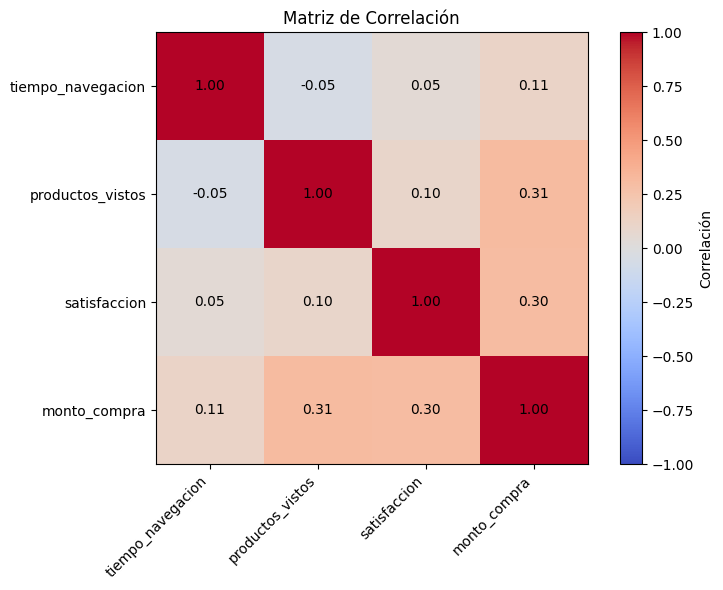

In [11]:
variables = ['tiempo_navegacion', 'productos_vistos', 'satisfaccion', 'monto_compra']
correlation_matrix = df[variables].corr()

plt.figure(figsize=(8, 6))
plt.imshow(correlation_matrix, cmap='coolwarm', interpolation='nearest', vmin=-1, vmax=1)
plt.colorbar(label='Correlación')
plt.xticks(range(len(variables)), variables, rotation=45, ha='right')
plt.yticks(range(len(variables)), variables)

for i in range(len(variables)):
    for j in range(len(variables)):
        plt.text(j, i, f'{correlation_matrix.iloc[i, j]:.2f}', ha='center', va='center', color='black')

plt.title('Matriz de Correlación')
plt.tight_layout()
plt.show()

**Respuesta:** No existe ninguna correlación lineal fuerte (mayor a 0.70) entre las variables $tiempo\_navegacion$, $productos\_vistos$, $satisfaccion$, $monto\_compra$.

In [12]:
X = df[['tiempo_navegacion', 'productos_vistos', 'satisfaccion']]
y = df['monto_compra']

X = sm.add_constant(X)
modelo = sm.OLS(y, X).fit()

print(modelo.summary())

                            OLS Regression Results                            
Dep. Variable:           monto_compra   R-squared:                       0.184
Model:                            OLS   Adj. R-squared:                  0.179
Method:                 Least Squares   F-statistic:                     37.27
Date:                Mon, 29 Dec 2025   Prob (F-statistic):           9.82e-22
Time:                        19:24:53   Log-Likelihood:                -3301.9
No. Observations:                 500   AIC:                             6612.
Df Residuals:                     496   BIC:                             6629.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
const              -208.7048     39.63

**Observación:** En el modelo de regresión lineal múltiple que considera el tiempo de navegación, la cantidad de productos vistos, y la satisfacción del cliente; para predecir el monto de compra del usuario todas las variables son representativas pues tienen un *p-value < 0.05*. Sin embargo, dicho modelo solo explica el 17.90% de la variabilidad del monto de compra. Por lo tanto, el modelo construido no es viable para predecir este valor.

In [13]:
X_without_const = X.drop(columns='const')

vif = pd.DataFrame()
vif["Variable"] = X_without_const.columns
vif["VIF"] = [
    variance_inflation_factor(X_without_const.values, i)
    for i in range(X_without_const.shape[1])
]
display(vif)

,Variable,VIF
0,tiempo_navegacion,1.863235
1,productos_vistos,5.249135
2,satisfaccion,6.060745


**Respuesta:** Ninguna de las variables del modelo de regresión lineal múltiple tiene un índice VIF muy fuerte (mayor a 0.7). Por lo tanto, se puede concluir que no existe una multicolinealidad significativa en el modelo construido.

## 2. Ajuste y Depuración del Modelo

---

**Orden:**
- Realice un proceso iterativo eliminando las variables que no sean estadísticamente significativas (p-valor > 0.05) hasta obtener un 
modelo final robusto. 
- Presente la ecuación final de regresión.

---

**Observación:** En el análisis desarrollado en el paso anterior, se determinó que todas las variables propuestas son estadísticamente significativas. Por lo tanto solo se realizará una selección de características con el método *step-forward* para intentar mejorar la métrica de $R^2$ ajustado.

In [14]:
# Dividir datos
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Selección forward simple
included = []
best_adj_r2 = -np.inf

while True:
    excluded = list(set(X_train.columns) - set(included))
    best_new_adj_r2 = -np.inf
    best_feature = None
    
    for new_column in excluded:
        X_current = sm.add_constant(X_train[included + [new_column]])
        model = sm.OLS(y_train, X_current).fit()
        
        if model.rsquared_adj > best_new_adj_r2:
            best_new_adj_r2 = model.rsquared_adj
            best_feature = new_column
    
    if best_new_adj_r2 > best_adj_r2:
        included.append(best_feature)
        best_adj_r2 = best_new_adj_r2
    else:
        break

if 'const' in included:
    included.remove('const')

X_final = sm.add_constant(df[included])
model = sm.OLS(y, X_final).fit()

print("\n=== RESUMEN DEL MODELO SELECCIONADO ===")
print(model.summary())


=== RESUMEN DEL MODELO SELECCIONADO ===
                            OLS Regression Results                            
Dep. Variable:           monto_compra   R-squared:                       0.184
Model:                            OLS   Adj. R-squared:                  0.179
Method:                 Least Squares   F-statistic:                     37.27
Date:                Mon, 29 Dec 2025   Prob (F-statistic):           9.82e-22
Time:                        19:24:53   Log-Likelihood:                -3301.9
No. Observations:                 500   AIC:                             6612.
Df Residuals:                     496   BIC:                             6629.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------

**Observación:** Aún aplicando el método de selección de características *step-forward*, le modelo no mejora. Por lo tanto, se puede concluir que la cantidad de productos vistos, la satisfación del cliente, y el tiempo de navegación no son suficientes para predecir el monto de compra.

**Respuesta:** El modelo de regresión múltiple más robusto obtenido con las variables de cantidad de productos vistos, la satisfación del cliente, y el tiempo de navegación explica la variabilidad del monto de compra un 17.90%. Además, presenta la siguiente ecuación:

$$
monto\_compra = -208.70 
+ 21.11 \cdot productos\_vistos 
+ 57.09 \cdot satisfaccion 
+ 1.23 \cdot tiempo\_navegacion
$$

Esto implica que, en ausencia de las demás variables, el modelo estima un monto de compra negativo, lo cual no tiene una interpretación práctica directa, pero forma parte del ajuste del modelo. Manteniendo constantes las demás variables, cada producto adicional visto incrementa el monto de compra en 21.11 dólares, cada punto de satisfacción aumenta el monto en 57.09 dólares, y cada unidad adicional de tiempo de navegación aporta 1.23 dólares al valor de la transacción.

## 4. Validación de Supuestos

---

**Orden:** Verifique gráficamente los supuestos de Linealidad, Normalidad (Q-Q plot), y Homocedasticidad del modelo final. 

---

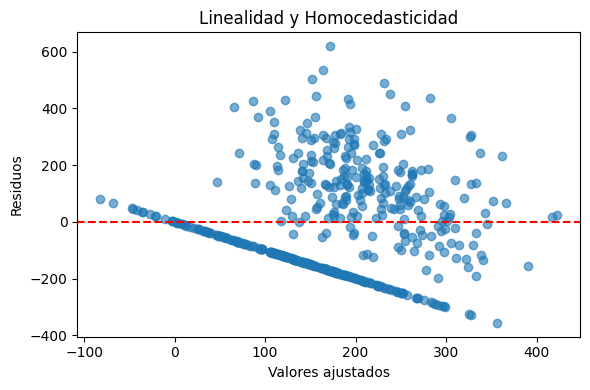

In [15]:
residuals = model.resid
fitted_values = model.fittedvalues

plt.figure(figsize=(6, 4))
plt.scatter(fitted_values, residuals, alpha=0.6)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('Valores ajustados')
plt.ylabel('Residuos')
plt.title('Linealidad y Homocedasticidad')
plt.tight_layout()
plt.show()

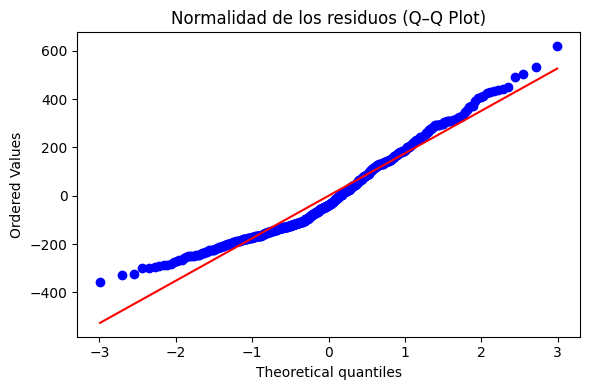

In [16]:
plt.figure(figsize=(6, 4))
stats.probplot(residuals, dist="norm", plot=plt)
plt.title('Normalidad de los residuos (Q–Q Plot)')
plt.tight_layout()
plt.show()

**Respuesta:** El modelo de regresión lineal múltiple no cumple con ninguno de los supuestos. De forma que se puede confirmar que el modelo construir a partir de las variables descritas anteriormente no es viable para predecir el monto de compra.

## 4. Predicción y Toma de Decisiones

---

**Orden:** Utilizando el modelo final, prediga el monto de compra para un "Cliente Promedio con Chatbot" que tiene los siguientes valores: 
- tiempo_navegacion: Mediana del dataset. 
- productos_vistos: Mediana del dataset. 
- satisfaccion: Mediana del dataset. 

Basado en los coeficientes estandarizados: ¿Qué variable tiene mayor influencia en el monto de compra y qué estrategia recomendaría para aumentarla?.

---

In [17]:
df_filtered = df[df['uso_chatbot_ia'] == 'Si']

median_tiempo_navegacion = df_filtered['tiempo_navegacion'].median()
median_productos_vistos = df_filtered['productos_vistos'].median()
median_satisfaccion = df_filtered['satisfaccion'].median()

y2 = (model.params['const'] +
    model.params['tiempo_navegacion'] * median_tiempo_navegacion +
    model.params['productos_vistos'] * median_productos_vistos +
    model.params['satisfaccion'] * median_satisfaccion)

print(f'Predicción del monto_compra para un cliente con valores medianos en las variables independientes: {y2:.2f}')

Predicción del monto_compra para un cliente con valores medianos en las variables independientes: 161.54


In [18]:
scaler_X = StandardScaler()
scaler_y = StandardScaler()

X_std = scaler_X.fit_transform(df[included])
y_std = scaler_y.fit_transform(y.values.reshape(-1, 1)).ravel()

X_std = sm.add_constant(X_std)

model_std = sm.OLS(y_std, X_std).fit()

standarized_betas = pd.Series(
    model_std.params[1:],
    index=included
)

print("\nCoeficientes estandarizados (Betas):")
print(standarized_betas)


Coeficientes estandarizados (Betas):
productos_vistos     0.291801
satisfaccion         0.266650
tiempo_navegacion    0.115130
dtype: float64


**Respuesta:** El cliente promedio que usa el chatbot gasta en promedio 161.54 dólares. Los coeficientes estandarizados del modelo de regresión lineal múltiple indican que la cantidad de productos vistos aporta más al monto de compra promedio. Por lo tanto se sugiere modificar la página web para que aparezcan más sugerencias de productos que le pueden interesar al cliente, haciendo que sean visibles y amigables.